# Aula 18 — Commodities do agro: conversões, futuro teórico e hedge

**Semana 9** | 50 min | Referências: McKinney (2012), *Python for Data Analysis* —
Cap. 10 *Time Series* (`kb/01_mckinney_python_for_data_analysis/12_chapter-10-time-series.md`);
Jansen (2021), *ML for Algorithmic Trading* — Cap. 1
(`kb/03_jansen_ml_for_algorithmic_trading/07_chapter-1-machine-learning-for-trading-from-idea-to-executio.md`)
e Cap. 2 (`kb/03_jansen_ml_for_algorithmic_trading/08_chapter-2-market-and-fundamental-data-sources-and-techniques.md`).

Aula anterior: A17 (séries temporais financeiras) · Próxima: A19 (regressão com sklearn)


## 🎯 Objetivos de aprendizagem

Ao final desta aula você será capaz de:

- Ler **cotações de commodities** em unidades internacionais (US$/bushel, US$/lb) e
  convertê-las para as unidades do mercado físico goiano (R$/saca de 60 kg, R$/arroba);
- Calcular o **preço futuro teórico** $F = S\,e^{(r+c-y)T}$ e a versão simplificada
  $F \approx S(1+rT)$, entendendo cada termo (custo de carregamento, yield);
- Medir a **base** (spot local − futuro) e discutir frete, qualidade e sazonalidade;
- Simular o **hedge do produtor** com venda antecipada no futuro e calcular o
  resultado final: `spot_final + (F0 − Ft)`.


## 📂 Dados da aula (offline-first)

| arquivo | conteúdo | unidade |
|---|---|---|
| `../data/csv/soja_cbot_usd_bushel.csv` | futuro soja CBOT (ZS=F) | US$/bushel |
| `../data/csv/milho_cbot_usd_bushel.csv` | futuro milho CBOT (ZC=F) | US$/bushel |
| `../data/csv/boi_gordo_cme_usd_lbs.csv` | futuro boi gordo CME (LE=F) | US$/libra |
| `../data/csv/usdbrl_diario.csv` | câmbio PTAX diário (BCB-SGS 1) | R$/US$ |

Números de referência (set/2026): câmbio ≈ **R$ 5,12**/US$; Selic ≈ **13,9% a.a.**;
soja CBOT ≈ **US$ 12,9/bu**; milho ≈ **US$ 5,1/bu**; boi CME ≈ **US$ 2,13/lb**.

In [1]:
# Setup — imports e padrões visuais usados na aula
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

def brl(x):
    """Formata um número como moeda brasileira: R$ 1.234,56."""
    return f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

np.random.seed(42)  # reprodutibilidade quando houver aleatoriedade

from pathlib import Path
DATA = Path("../data/csv")  # notebook mora em semana_09/

print("pandas:", pd.__version__)


pandas: 3.0.5


## 1. O agro goiano é um mercado de commodities — e de duas moedas

**Intuição econômica.** O produtor de **Rio Verde** ou **Jataí** vende sua soja
duas vezes: fisicamente, na roça, em **R$/saca de 60 kg**; e financeiramente, no
papel, em **US$/bushel** na CBOT (Chicago). O preço que ele recebe é o preço de
Chicago **traduzido**: convertido de bushel para saca e de dólar para real.

Duas unidades, duas moedas — e a conversão é a primeira tarefa de qualquer análise
agro. As regras:

- **Soja/milho**: 1 bushel de soja = **27,216 kg**; a saca brasileira tem 60 kg.
  Então 1 saca = 60/27,216 = 2,2046 bushels. **R$/sc = US$/bu × 2,2046 × câmbio**.
  (Para milho: 1 bu = 25,401 kg → 1 sc de 60 kg = 2,3622 bu.)
- **Boi**: CME negocia US$/libra-peso (lb); a arroba brasileira tem 15 kg de carcaça
  = 33,069 lb. **R$/@ = US$/lb × 33,069 × câmbio**.

O câmbio é o **segundo preço** do produtor: soja a US$ 12,9/bu vale mais ou menos
em reais dependendo do dólar do dia — e é por isso que a Aula 17 (séries de câmbio)
veio antes desta.

In [2]:
# Carregando as 4 séries da aula — padrão de datas ISO do Yahoo + BCB pt-BR
soja = pd.read_csv(DATA / "soja_cbot_usd_bushel.csv")
milho = pd.read_csv(DATA / "milho_cbot_usd_bushel.csv")
boi = pd.read_csv(DATA / "boi_gordo_cme_usd_lbs.csv")
usd = pd.read_csv(DATA / "usdbrl_diario.csv", sep=";", decimal=",")

for df, col in [(soja, "date"), (milho, "date"), (boi, "date")]:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d")

usd["data"] = pd.to_datetime(usd["data"], format="%d/%m/%Y", dayfirst=True)

soja = soja.set_index("date").sort_index()["close"]
milho = milho.set_index("date").sort_index()["close"]
boi = boi.set_index("date").sort_index()["close"]
usd = usd.set_index("data").sort_index()["valor"]

print("câmbio último:", usd.iloc[-1], "| soja último:",
      f"US$ {soja.iloc[-1]/100:.2f}/bu")


câmbio último: 5.1253 | soja último: US$ 12.94/bu


## 2. Conversões: de Chicago para a saca de Rio Verde

**Intuição econômica.** O cliente pergunta: "com a soja a US$ 12,9 e o dólar a
R$ 5,12, quanto sobra por saca?". A conta tem duas etapas — unidade e moeda —
e é a mesma linha de pandas para a série inteira:

$$P_{\text{sc}} = P_{\text{bu}} \times \frac{60}{27{,}216} \times \text{câmbio}$$

O inverso também importa: quando o **dólar cai** e Chicago **sobe**, a conversão
mostra qual força venceu — a competição entre preço internacional e câmbio é o
cotidiano do agro brasileiro.

In [3]:
# Conversão soja: US$/bu -> R$/sc de 60 kg (fator 60/27,216 = 2,2046)
CAMBIO = usd.reindex(soja.index, method="ffill")   # câmbio do último dia útil anterior
fator_sc = 60 / 27.216                             # 2,2046 bu/sc

soja_rsc = soja / 100 * fator_sc * CAMBIO          # US$/bu -> US$/sc -> R$/sc (vetorizado)

print(f"hoje: US$ {soja.iloc[-1]/100:.2f}/bu x 2,2046 x R$ {CAMBIO.iloc[-1]:.2f}")
print("= ", brl(soja_rsc.iloc[-1]), "/saca de 60 kg")


hoje: US$ 12.94/bu x 2,2046 x R$ 5.13
=  R$ 146,18 /saca de 60 kg


In [4]:
# Milho (1 bu = 25,401 kg) e boi (1 arroba = 33,069 lb) — mesmas duas etapas
fator_sc_milho = 60 / 25.401                       # 2,3622 bu/sc
CAMBIO_M = usd.reindex(milho.index, method="ffill")
milho_rsc = milho / 100 * fator_sc_milho * CAMBIO_M

CAMBIO_B = usd.reindex(boi.index, method="ffill")
boi_ra = boi / 100 * 33.069 * CAMBIO_B             # US$/lb -> US$/@ -> R$/@

amostra = pd.DataFrame({
    "soja R$/sc": soja_rsc.loc['2026'].resample('ME').mean(),
    "milho R$/sc": milho_rsc.loc['2026'].resample('ME').mean(),
    "boi R$/@": boi_ra.loc['2026'].resample('ME').mean(),
}).dropna()
print(amostra.round(1))


            soja R$/sc  milho R$/sc  boi R$/@
date                                         
2026-01-31       123.8         54.3     414.8
2026-02-28       128.8         52.8     417.5
2026-03-31       135.0         55.9     406.2
2026-04-30       129.5         53.8     415.9
2026-05-31       131.2         54.3     413.9
2026-06-30       127.2         50.6     427.8
2026-07-31       134.8         53.6     390.9
2026-08-31       136.2         57.1     384.8
2026-09-30       147.2         62.6     360.0


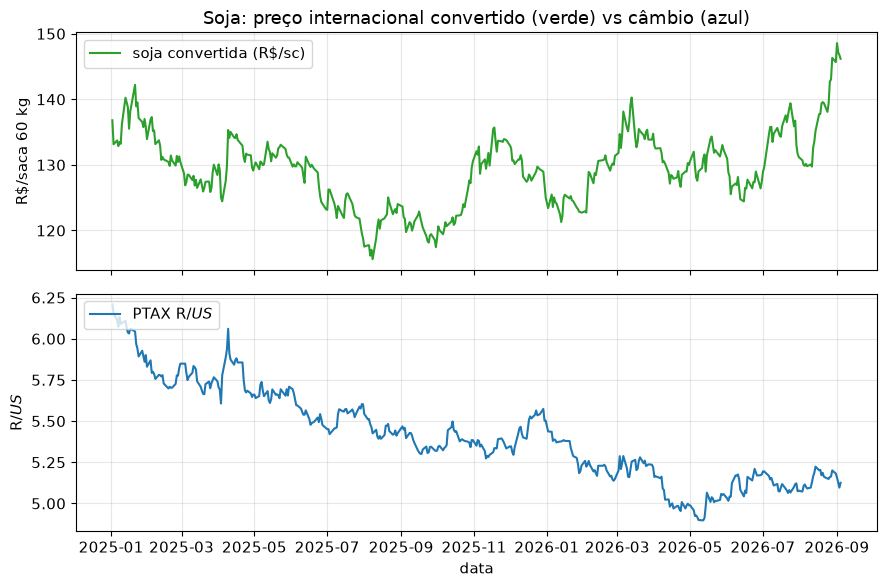

In [5]:
# O duelo do ano: preço internacional x câmbio — quem venceu em 2025?
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax1.plot(soja_rsc.loc['2025':], color="tab:green", label="soja convertida (R$/sc)")
ax1.set_ylabel("R$/saca 60 kg")
ax1.set_title("Soja: preço internacional convertido (verde) vs câmbio (azul)")
ax1.legend(loc="upper left")

ax2.plot(CAMBIO.loc['2025':], color="tab:blue", label="PTAX R$/US$")
ax2.set_ylabel("R$/US$")
ax2.set_xlabel("data")
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()


## 3. Preço futuro teórico: o custo de esperar

**Intuição econômica.** Por que o futuro para dezembro não custa o mesmo que a soja
de hoje? Porque **carregar a commodity até lá custa dinheiro**: quem guarda soja
deixa de render Selic (custo de oportunidade $r$), paga armazenagem ($c$) e ganha
o aluguel do produto (yield $y$). A arbitragem fecha o preço na fórmula do
**cost-of-carry**:

$$F = S \cdot e^{(r + c - y)\,T}$$

com $S$ = spot (preço à vista), $r$ = taxa de juros (Selic), $c$ = custo de
armazenagem/seguro, $y$ = conveniência/aluguel, $T$ = prazo em anos. No Brasil,
$r$ domina: com Selic de 13,9% a.a., a soja guardada 3 meses "cresce" ~3,4% só de
juro embutido.

Versão **simplificada** que usaremos (sem $c$ e $y$, juros simples):

$$F \approx S \,(1 + r\,T)$$

Comparando esse $F$ teórico com o futuro real da CBOT convertido, aparece a **base**
da próxima seção.

In [6]:
# Preço futuro teórico da soja — Selic 13,9% a.a. como r (set/2026)
r = 0.139        # Selic a.a. (custo de oportunidade de carregar estoque)
T = 0.25         # 3 meses até o vencimento (futuro " próximo")

S = soja_rsc.iloc[-1]                # spot convertido: R$/sc hoje
F_teorico = S * (1 + r * T)          # aproximação de juros simples
F_exp = S * np.exp(r * T)            # versão contínua da fórmula do cap. 2 (Jansen)

print(f"spot S        = {brl(S)}/sc")
print(f"F simplificado = {brl(F_teorico)}/sc (T=3m, r=13,9% a.a.)")
print(f"F contínuo     = {brl(F_exp)}/sc")
print(f"carry de 3m   = {100 * r * T:.2f}% sobre o spot")


spot S        = R$ 146,18/sc
F simplificado = R$ 151,26/sc (T=3m, r=13,9% a.a.)
F contínuo     = R$ 151,35/sc
carry de 3m   = 3.48% sobre o spot


## 4. Base: o preço local fala do frete e da qualidade

**Intuição econômica.** O preço que o produtor de Rio Verde vê na praça **não** é o
futuro de Chicago convertido — é o futuro **menos frete, prêmio/desconto de
qualidade e sazonalidade**. A diferença tem nome: **base**.

$$\text{base} = S_{\text{local}} - F$$

- Base **negativa** (comum no Brasil): local abaixo do futuro — frete até o porto,
  custos de logística;
- Base **positiva**: escassez local ou prêmio de qualidade;
- A base **oscila com a safra**: cheia de oferta, base afunda; entre safras, recupera
  (sazonalidade).

Vamos usar um spot **fictício** de Rio Verde para ilustrar — o ponto didático é o
cálculo e a leitura, não o número oficial.

In [7]:
# Base da soja em Rio Verde (spot fictício para fins didáticos)
spot_rio_verde = 138.0    # R$/sc — valor ilustrativo, mercado físico de Rio Verde
futuro_conv = soja_rsc.iloc[-1]   # futuro CBOT convertido (proxy do vencimento próximo)

base = spot_rio_verde - futuro_conv

print(f"spot Rio Verde (fictício) : {brl(spot_rio_verde)}/sc")
print(f"futuro convertido         : {brl(futuro_conv)}/sc")
print(f"base                      : {brl(base)}/sc  ({100 * base / futuro_conv:+.1f}% do futuro)")
print("\nleitura: base negativa = local paga menos que Chicago (frete, logística)")


spot Rio Verde (fictício) : R$ 138,00/sc
futuro convertido         : R$ 146,18/sc
base                      : R$ -8,18/sc  (-5.6% do futuro)

leitura: base negativa = local paga menos que Chicago (frete, logística)


## 5. Hedge do produtor: vender o que ainda não colheu

**Intuição econômica.** O produtor planta em outubro e colhe em fevereiro. Entre
uma data e outra, o preço da soja pode derreter — e a receita dele vai junto. O
**hedge** clássico: **vender futuro hoje** (compromisso de entregar/vender pelo
preço $F_0$) e desmontar a posição na colheita, vendendo o físico pelo spot de lá.

O resultado do produtor com hedge (por saca):

$$\text{resultado} = S_t + (F_0 - F_t)$$

- Colheu com preço alto ($S_t$ alto)? O futuro subiu ($F_t > F_0$) e o hedge **perde**
  $F_0 - F_t$ — o produtor recebe menos, mas **recebe o mesmo** que travou;
- Colheu com preço derretido ($S_t$ baixo)? O futuro caiu, o hedge **ganha** — e a
  receita é resgatada.

O hedge **não** enriquece: **trava** a receita em ~$F_0$ (convertido), tirando a
aposta de preço do balanço. É seguro, não aposta.

In [8]:
# Simulação de hedge: venda futura em 14/ago/2026, colheita 04/set/2026
t0, t1 = '2026-08-14', '2026-09-04'          # venda do hedge -> desmontagem

F0_usd = soja.loc[t0]                        # futuro vendido (US$/bu)
Ft_usd = soja.loc[t1]
cam0 = usd.loc[t0]                           # câmbio de cada data
camt = usd.loc[t1]

F0 = F0_usd / 100 * fator_sc * cam0          # preço futuro em R$/sc (equiv. do hedge)
Ft = Ft_usd / 100 * fator_sc * camt

# spot de colheita fictício: segue o futuro convertido (mercado eficiente)
S0 = soja_rsc.loc[t0]
St = S0 * (Ft_usd / F0_usd) * (camt / cam0)

sem_hedge = St
com_hedge = St + (F0 - Ft)

print(f"F0 = {brl(F0)}/sc | Ft = {brl(Ft)}/sc")
print(f"spot na colheita (fictício) = {brl(St)}/sc")
print(f"\nreceita SEM hedge : {brl(sem_hedge)}/sc")
print(f"receita COM hedge : {brl(com_hedge)}/sc  ->  travada perto de F0 = {brl(F0)}")


F0 = R$ 135,17/sc | Ft = R$ 146,18/sc
spot na colheita (fictício) = R$ 146,18/sc

receita SEM hedge : R$ 146,18/sc
receita COM hedge : R$ 135,17/sc  ->  travada perto de F0 = R$ 135,17


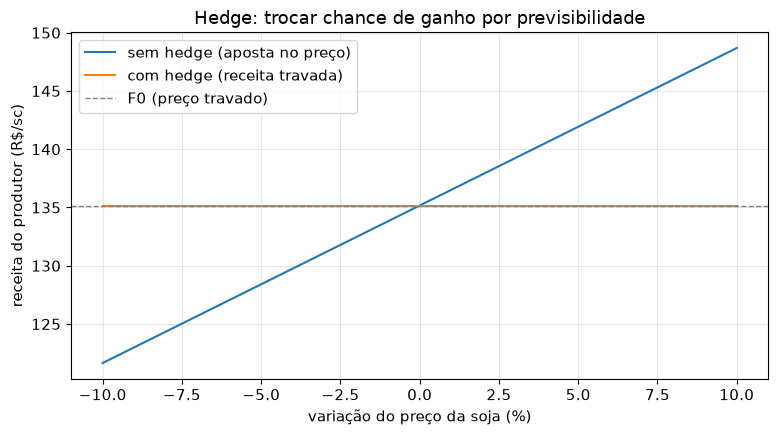

In [9]:
# A receita com hedge fica quase plana: o gráfico que resume a ideia do hedge
# (variação fictícia do futuro: -10% a +10% em torno de F0)
cenarios = np.linspace(-0.10, 0.10, 21)            # 21 cenários de variação do futuro
Ft_cen = F0 * (1 + cenarios)                       # futuro na colheita, por cenário
St_cen = S0 * (1 + cenarios)                       # spot acompanha o futuro (base ~const.)

receita_sem = St_cen
receita_com = St_cen + (F0 - Ft_cen)               # compensação simétrica

fig, ax = plt.subplots()
ax.plot(100 * cenarios, receita_sem, label="sem hedge (aposta no preço)")
ax.plot(100 * cenarios, receita_com, label="com hedge (receita travada)")
ax.axhline(F0, color="gray", ls="--", lw=1, label="F0 (preço travado)")
ax.set_xlabel("variação do preço da soja (%)")
ax.set_ylabel("receita do produtor (R$/sc)")
ax.set_title("Hedge: trocar chance de ganho por previsibilidade")
ax.legend()
plt.show()


## 📝 Exercícios

Faça **antes** de abrir a solução. Todos usam as séries já carregadas e as
conversões da aula.

### Exercício 1 — Conversão do milho de Rio Verde

Com a série `milho` (US$/bu) e o câmbio de cada dia:

a) converta para R$/sc de 60 kg (1 bu = 25,401 kg de milho);
b) informe o valor **mais recente**;
c) calcule a média mensal de 2026 (`resample('ME')`) e diga o mês mais caro.

In [10]:
# EXERCÍCIO 1 — seu código aqui


In [11]:
# SOLUÇÃO 1
fator_milho = 60 / 25.401
CAMBIO_m = usd.reindex(milho.index, method="ffill")
milho_rsc = milho / 100 * fator_milho * CAMBIO_m

print("milho hoje:", brl(milho_rsc.iloc[-1]), "/sc de 60 kg")

mensal = milho_rsc.loc['2026'].resample('ME').mean()
print("mês mais caro de 2026:", mensal.idxmax().strftime('%b/%Y'),
      "—", brl(mensal.max()))


milho hoje: R$ 61,99 /sc de 60 kg
mês mais caro de 2026: Sep/2026 — R$ 62,59


### Exercício 2 — O boi em arroba

A CME cota o boi gordo em US$/libra. Converta para R$/arroba (1 @ = 33,069 lb) e:

a) diga o valor atual;
b) calcule a variação percentual em 2026 (`pct_change().cumsum()` ou
   `(1+r).cumprod()`);
c) compare com o duelo câmbio × preço internacional: o que puxou o boi em 2026?

In [12]:
# EXERCÍCIO 2 — seu código aqui


In [13]:
# SOLUÇÃO 2
CAMBIO_b = usd.reindex(boi.index, method="ffill")
boi_ra = boi / 100 * 33.069 * CAMBIO_b

print("boi hoje:", brl(boi_ra.iloc[-1]), "/arroba")

ret_2026 = (1 + boi.pct_change().loc['2026']).cumprod() - 1
print(f"variação do boi (US$) em 2026: {100 * ret_2026.iloc[-1]:+.1f}%")

ret_cam = (1 + usd.pct_change().loc['2026']).cumprod() - 1
print(f"variação do câmbio em 2026   : {100 * ret_cam.iloc[-1]:+.1f}%")
print("leitura: preço em US$ e câmbio somam forças (ou disputam) na receita em R$")


boi hoje: R$ 360,93 /arroba
variação do boi (US$) em 2026: -8.2%
variação do câmbio em 2026   : -6.9%
leitura: preço em US$ e câmbio somam forças (ou disputam) na receita em R$


### Exercício 3 — Futuro teórico vs futuro real da CBOT

Para a soja:

a) calcule $F$ teórico com $S$ = spot convertido de hoje, $r$ = 13,9% a.a.,
   $T$ = 0,25 ano;
b) compare com o futuro CBOT convertido (`soja_rsc.iloc[-1]`);
c) a diferença é a **base** implícita (negativa). Comente frete e qualidade.

In [14]:
# EXERCÍCIO 3 — seu código aqui


In [15]:
# SOLUÇÃO 3
S_hoje = soja_rsc.iloc[-1]
F_teorico_ex = S_hoje * (1 + 0.139 * 0.25)

print(f"F teórico 3m  : {brl(F_teorico_ex)}/sc")
print(f"futuro CBOT   : {brl(soja_rsc.iloc[-1])}/sc")
print(f"base implícita: {brl(S_hoje - F_teorico_ex)}/sc")
print("base negativa típica do Centro-Oeste: frete Rio Verde→portos, qualidade, oferta local")


F teórico 3m  : R$ 151,26/sc
futuro CBOT   : R$ 146,18/sc
base implícita: R$ -5,08/sc
base negativa típica do Centro-Oeste: frete Rio Verde→portos, qualidade, oferta local


### Exercício 4 — Hedge com o milho

Um produtor de **Jataí** vende futuro de milho em `t0 = '2026-08-14'` e desmonta em
`t1 = '2026-09-04'`:

a) calcule $F_0$ e $F_t$ em R$/sc (fator 60/25,401);
b) assuma spot fictício $S_0$ = futuro convertido em `t0` e $S_t$ = futuro convertido
   em `t1`;
c) calcule o resultado do hedge: $S_t + (F_0 - F_t)$. Compare com não fazer hedge.

In [16]:
# EXERCÍCIO 4 — seu código aqui


In [17]:
# SOLUÇÃO 4
t0, t1 = '2026-08-14', '2026-09-04'
fator_m = 60 / 25.401

F0_m = milho.loc[t0] / 100 * fator_m * usd.loc[t0]
Ft_m = milho.loc[t1] / 100 * fator_m * usd.loc[t1]

S0_m = F0_m                                   # spot fictício = futuro convertido
St_m = milho.loc[t1] / 100 * fator_m * usd.loc[t1]

print(f"sem hedge: {brl(St_m)}/sc")
print(f"com hedge: {brl(St_m + (F0_m - Ft_m))}/sc ≈ F0 = {brl(F0_m)}")
print("hedge trava a receita: nem derrete, nem dispara — previsibilidade para o caixa")


sem hedge: R$ 61,99/sc
com hedge: R$ 56,63/sc ≈ F0 = R$ 56,63
hedge trava a receita: nem derrete, nem dispara — previsibilidade para o caixa


## 📌 Resumo & para casa

- Commodities cotam em **unidades e moedas estrangeiras**: converter unidade
  (bu→saca: ×60/27,216 soja; ×60/25,401 milho; lb→arroba: ×33,069) e moeda
  (×câmbio do dia, alinhado com `reindex(method='ffill')`);
- **Futuro teórico** (cost-of-carry): $F = S e^{(r+c-y)T}$; versão aula:
  $F \approx S(1+rT)$ com Selic 13,9% a.a.;
- **Base** = spot local − futuro: frete, qualidade e sazonalidade vivem ali;
- **Hedge do produtor**: venda futura hoje, desmonte na colheita — resultado
  $S_t + (F_0 - F_t)$ fica travado perto de $F_0$: seguro, não aposta;
- Toda conversão é uma linha vetorizada — Aula 17 (séries temporais) + Aula 8
  (ufuncs) trabalhando juntas.

**Para casa:** refaça o hedge da soja assumindo que a **base melhora 3 R$/sc**
entre a venda e a colheita (safra cheia → safrinha). O resultado deixa de ser
exatamente $F_0$? Por quê?

**Próxima aula (A19):** regressão com scikit-learn — usar variáveis (câmbio,
preço internacional) para **explicar** o preço local, em vez de só convertê-lo.

**Referências (KB):**
- `kb/01_mckinney_python_for_data_analysis/12_chapter-10-time-series.md` — Cap. 10:
  manipulação das séries de preços (rolling, resample, shift);
- `kb/03_jansen_ml_for_algorithmic_trading/07_chapter-1-machine-learning-for-trading-from-idea-to-executio.md`
  — Cap. 1: do dado à decisão de trading (mercados, alavancagem, hedge);
- `kb/03_jansen_ml_for_algorithmic_trading/08_chapter-2-market-and-fundamental-data-sources-and-techniques.md`
  — Cap. 2: fontes de dados de mercado e fundamentalistas (futuros, barris, bushels).